Lab 4
Jack Schwyn

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

ModuleNotFoundError: No module named 'pandas'

First we want to import all of the necessary libraries.

In [1]:
originaldata = pd.read_csv("HousingData.csv") #Importing original dataset.
#df = originaldata.dropna()
df

NameError: name 'pd' is not defined

Here is the dataset wihtout the "NAs".

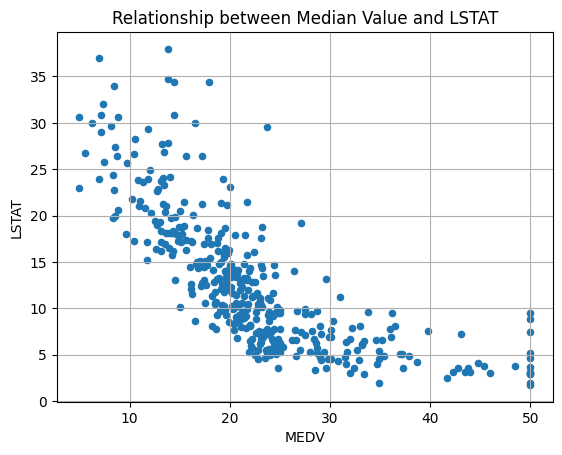

In [4]:
#Data visulizaiotns
#Scatter Plot
df.plot.scatter(x = 'MEDV', y = 'LSTAT') #Showing a relationship between Median Value and LSTAT.
plt.title("Relationship between Median Value and LSTAT")
plt.grid()
plt.show()

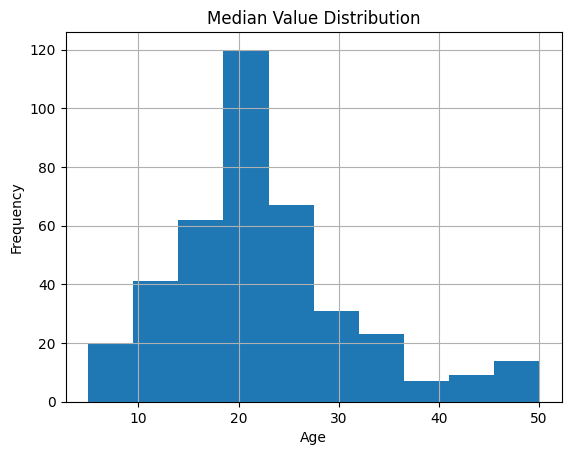

In [5]:
#Simple Histogram
medvarray = df[['MEDV']].to_numpy()
plt.hist(medvarray)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Median Value Distribution")
plt.grid()
plt.show()

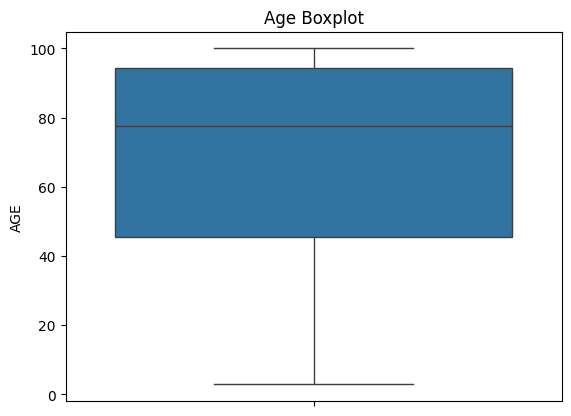

<Figure size 1000x1000 with 0 Axes>

In [6]:
#Simple Box Plot
sns.boxplot(y = 'AGE', data = df)
plt.title("Age Boxplot")
plt.figure(figsize = (10, 10))
plt.show()

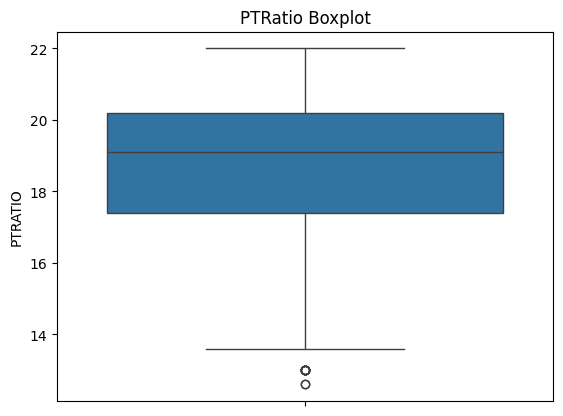

<Figure size 1000x1000 with 0 Axes>

In [7]:
#Simple Box Plot to look for outliers
sns.boxplot(y = 'PTRATIO', data = df)
plt.title("PTRatio Boxplot")
plt.figure(figsize = (10, 10))
plt.show()

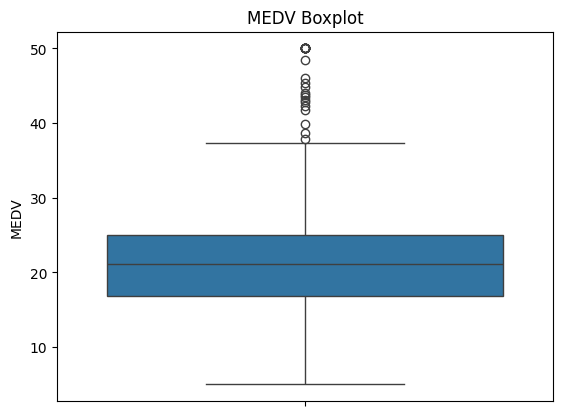

<Figure size 1000x1000 with 0 Axes>

In [8]:
#Looking for Outliers using boxplots.
sns.boxplot(y = 'MEDV', data = df) #Boxplot for MEDV.
plt.title("MEDV Boxplot")
plt.figure(figsize = (10, 10))
plt.show()

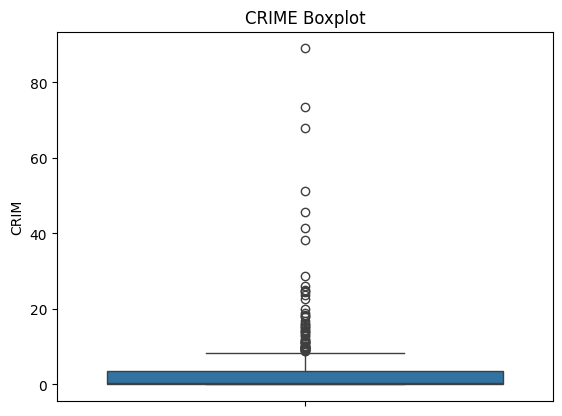

<Figure size 1000x1000 with 0 Axes>

In [9]:
#Looking for outliers
sns.boxplot(y = 'CRIM', data = df) #Boxplot for crime rates.
plt.title("CRIME Boxplot")
plt.figure(figsize = (10, 10))
plt.show()

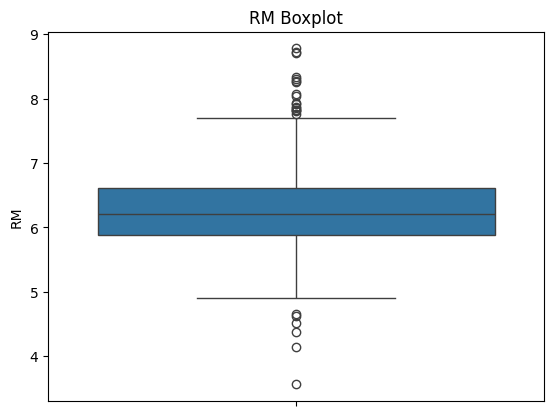

<Figure size 1000x1000 with 0 Axes>

In [10]:
#Looking for outliers
sns.boxplot(y = 'RM', data = df)
plt.title("RM Boxplot")
plt.figure(figsize = (10, 10))
plt.show()

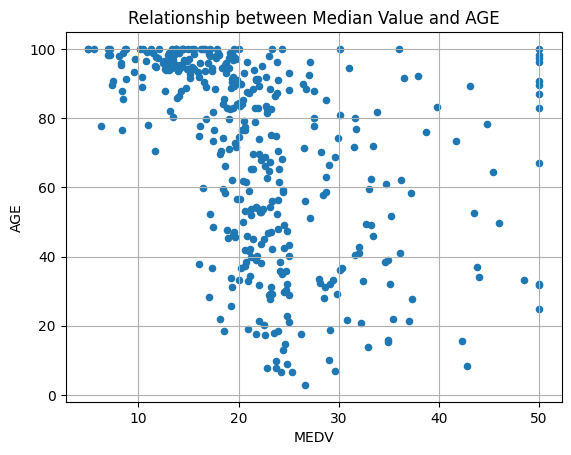

In [11]:
#Scatter plot between MEDV and Age.
df.plot.scatter(x = 'MEDV', y = 'AGE')
plt.title("Relationship between Median Value and AGE")
plt.grid()
plt.show()

<Figure size 2000x1000 with 0 Axes>

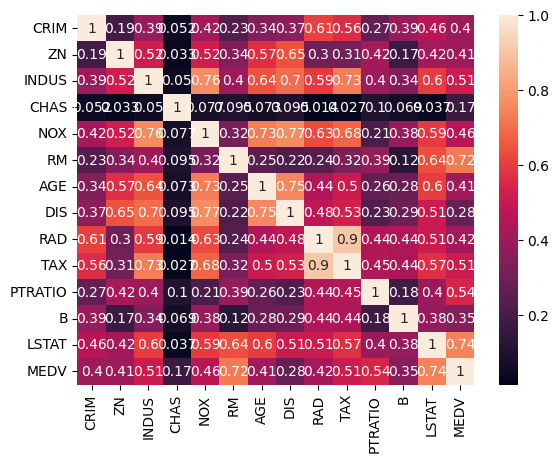

<Figure size 2000x1000 with 0 Axes>

In [12]:
#Looking for correlations based on a heatmap.
sns.heatmap(df.corr().abs(), annot = True)
plt.figure(figsize=(20,10))

From the heatmap, and the scatter plot, we can confidentaly say that MEDV and LSTAT have a strong correlation.
However, for the test split, we will use all of the columns to predict the MEDV.

In [13]:
#Finding and Removing Outliers
for k, v in df.items():
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    iqr = q3 - q1
    v_col = v[(v <= q1 - 1.5 * iqr) | (v >= q3 + 1.5 * iqr)]
    print("Column %s outlier: %.2f", (k, v_col)) #From this we will find the outliers for MEDV.

newdata = df[~(df['MEDV'] >= 36)] #Removing MEDV outliers. In my mind, we cannot remove every outier in every column, this will lead to the
#columns not having the same length. Again, this is just my opinion.
print(np.shape(newdata))

Column %s outlier: %.2f ('CRIM', 356     8.98296
371     9.23230
373    11.10810
374    18.49820
377     9.82349
378    23.64820
379    17.86670
380    88.97620
381    15.87440
382     9.18702
384    20.08490
385    16.81180
386    24.39380
387    22.59710
392    11.57790
395     8.71675
398    38.35180
399     9.91655
400    25.04610
402     9.59571
403    24.80170
404    41.52920
405    67.92080
410    51.13580
411    14.05070
412    18.81100
413    28.65580
414    45.74610
415    18.08460
416    10.83420
417    25.94060
418    73.53410
419    11.81230
420    11.08740
422    12.04820
424     8.79212
425    15.86030
431    10.06230
434    13.91340
435    11.16040
436    14.42080
437    15.17720
438    13.67810
439     9.39063
443     9.96654
444    12.80230
445    10.67180
447     9.92485
448     9.32909
454     9.51363
468    15.57570
469    13.07510
477    15.02340
478    10.23300
Name: CRIM, dtype: float64)
Column %s outlier: %.2f ('ZN', 39      75.0
40      75.0
54      75.0
55   

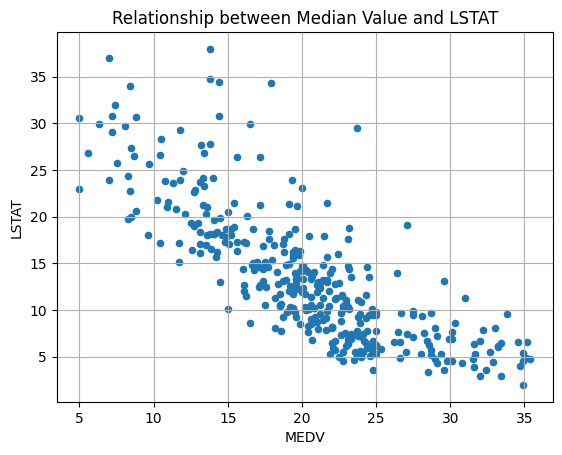

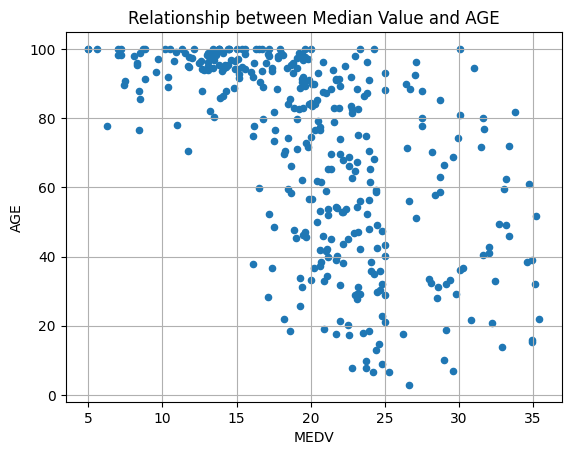

In [14]:
#Scatter plots after removing the outliers
newdata.plot.scatter(x = 'MEDV', y = 'LSTAT')
plt.title("Relationship between Median Value and LSTAT")
plt.grid()
plt.show()

newdata.plot.scatter(x = 'MEDV', y = 'AGE')
plt.title("Relationship between Median Value and AGE")
plt.grid()
plt.show()

In [15]:
#Multiple Linear Regression Model
x = newdata.drop('MEDV', axis = 1) #Separating the MEDV column from the rest of the data.
y = newdata['MEDV']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
print(x_test)
print(y_test)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
270  0.29916  20.0   6.96   0.0  0.464  5.856  42.1  4.4290    3  223   
364  3.47428   0.0  18.10   1.0  0.718  8.780  82.9  1.9047   24  666   
55   0.01311  90.0   1.22   0.0  0.403  7.249  21.9  8.6966    5  226   
30   1.13081   0.0   8.14   0.0  0.538  5.713  94.1  4.2330    4  307   
318  0.40202   0.0   9.90   0.0  0.544  6.382  67.2  3.5325    4  304   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
323  0.28392   0.0   7.38   0.0  0.493  5.708  74.3  4.7211    5  287   
96   0.11504   0.0   2.89   0.0  0.445  6.163  69.6  3.4952    2  276   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
174  0.08447   0.0   4.05   0.0  0.510  5.859  68.7  2.7019    5  296   
11   0.11747  12.5   7.87   0.0  0.524  6.009  82.9  6.2267    5  311   

     PTRATIO       B  LSTAT  
270     18.6  388.65  13.00  
364     20.2  354.55   5.29  
55      17.9  395.93   4.81  
30 

In [16]:
#Standard Scaling
sc = StandardScaler()
x_train = sc.fit_transform(x_train) #Transforming the training set into an array.
x_test = sc.transform(x_test) #Transforming the testing set into an array.
x_test

array([[-0.40901456,  0.42963863, -0.67398598, ..., -0.13617955,
         0.37878689, -0.10532183],
       [-0.06652579, -0.44143441,  0.95886823, ...,  0.68474584,
         0.03499617, -1.1636304 ],
       [-0.43986974,  3.47839423, -1.51533097, ..., -0.49533441,
         0.45218268, -1.22951731],
       ...,
       [-0.43833804, -0.44143441, -0.65786265, ..., -0.54664224,
         0.46196206, -0.63516244],
       [-0.43217239, -0.44143441, -1.10052151, ..., -1.16233628,
         0.42496171, -0.56653023],
       [-0.4286128 ,  0.10298624, -0.54060202, ..., -1.88064599,
         0.46196206, -0.06826044]])

In [18]:
#Training
regressor = LinearRegression() 
regressor.fit(x_train, y_train.values) #building the multiple linear regression model

LinearRegression()

In [20]:
y_pred = regressor.predict(x_train) #we are using the x_train values to predict the MEDV values.
np.set_printoptions(precision=2)
print(y_pred)

[11.82 16.68 23.34  8.07 29.77 14.21  8.35 20.12 30.37 20.99 32.23 11.71
 22.21 19.76 19.02 19.13 16.   12.95 21.52 19.18 24.99  5.56 16.55 22.66
 24.82 18.33 23.53 22.38 15.91 19.91 21.3  13.82 15.66 18.28 21.74 21.19
 25.41 28.19 27.65 19.27 21.44 17.99 25.38 27.34 20.47 23.89 21.66  8.45
 17.91 20.12 22.84 23.58 16.54 28.21  9.48 23.15 16.59 17.52 25.48 25.46
 24.18 13.9  16.12  6.89 20.2  21.95 19.46 28.01 22.8  33.01 22.34 10.99
 27.93 22.12 23.49 16.98 28.01 25.27 18.05 14.58 21.66 27.51 14.74  5.54
 18.75 22.53 19.58 24.41 23.04 17.95 23.04 27.18 15.17 29.47 24.86 24.19
 15.64 22.22 18.21 11.8  18.48 17.94 18.69 17.82 26.65 16.34 25.48 19.06
 15.04 25.4  30.97 26.71 12.23 14.41 19.58 15.22  6.88 16.   29.32 13.45
 26.53 18.98 27.33 20.66 18.16 15.71 20.77 20.59 25.8  20.61 19.56 18.8
 19.3  15.51 19.43 21.09 13.8   7.17 17.75 20.28 24.69 25.37 16.47 23.22
 26.92 16.06 26.88 27.13 25.35 15.1  22.33 25.39 17.33 19.77 20.55 19.43
 15.99 26.68 25.88 22.95 25.87 11.16 23.8  28.86 30.

In [21]:
#R2 Score
print("R2 Score", r2_score(y_train, y_pred))

R2 Score 0.8025820640755552


The r2 score indicates that the training model and the prediction model have a strong correlation.
If we test the prediction model, we should expect the MEDV values to be somewhat close to the original MEDV values.

In [22]:
#Testing

#Row 1
print(regressor.predict([[0.00632, 18, 2.31, 0, 0.538, 6.575, 65.2, 4.09, 1, 296, 15.3, 396.9, 4.98]]))

#Row 3
print(regressor.predict([[0.02729, 0, 7.07, 0, 0.469, 7.185, 61.1, 4.9671, 2, 242, 17.8, 392.83, 4.03]]))

#Row 6
print(regressor.predict([[0.02985, 0, 2.81, 0, 0.485, 6.43, 58.7, 6.0622, 3, 222, 18.7, 394.12, 5.12]]))

#Row 18
print(regressor.predict([[0.7842, 0, 8.14, 0, 0.538, 5.99, 81.7, 4.2579, 4, 307, 21, 386.75, 14.67]]))

[-450.6]
[-350.55]
[-310.9]
[-541.17]


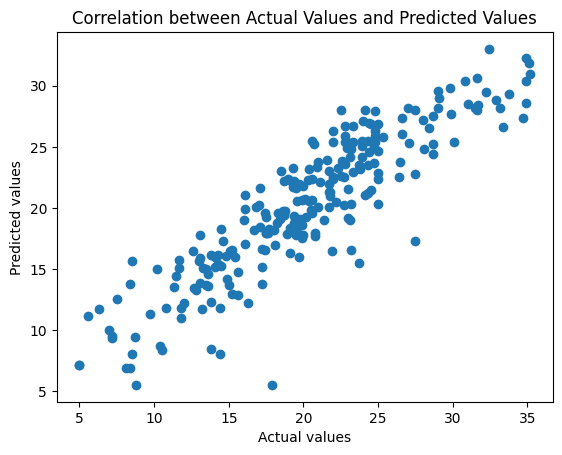

In [23]:
#Prediciton vs actual
plt.scatter(y_train, y_pred)
plt.title("Correlation between Actual Values and Predicted Values")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

Based on the scatter plot and the r2 score, we can say that our prediciton model is somewhat accurate. However, certain features like "LSTAT", and "PTRatio" share a strong correlation with the MEDV, which means that they would work best for the prediciton model, but since we are using all of the features, the correlation will become weaker. Features like "CHAS" and "B" do not have a strong correlation wiht MEDV, so in the future, they should not be included in the prediction model.